# Vehicle Classification CNN
Train a CNN to classify 8 types of vehicles using PyTorch.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import zipfile

PROJECT_DIR = '/content/drive/MyDrive/VehicleClassifier_Yi Lang'

# drive folder structure
RAW_DIR     = os.path.join(PROJECT_DIR, 'Data', 'Raw')        # put zip here
SPLITS_DIR  = os.path.join(PROJECT_DIR, 'Data', 'Processed')  # split data here
MODEL_DIR   = os.path.join(PROJECT_DIR, 'Results', 'Model')
LOG_DIR     = os.path.join(PROJECT_DIR, 'Results', 'Logs')
SUMMARY_DIR = os.path.join(PROJECT_DIR, 'Results', 'Summary')

for d in [RAW_DIR, SPLITS_DIR, MODEL_DIR, LOG_DIR, SUMMARY_DIR]:
    os.makedirs(d, exist_ok=True)

# zip location on drive
ZIP_PATH = os.path.join(RAW_DIR, 'vehicle_classification.zip')

# local storage
LOCAL_ZIP = '/content/vehicle_classification.zip'
LOCAL_DATA = '/content/data'

CLASSES = ['Bicycle', 'Bus', 'Car', 'Motorcycle', 'NonVehicles', 'Taxi', 'Truck', 'Van']

print('Folder structure:')
print(f'  Data/Raw:       {RAW_DIR}')
print(f'  Data/Processed: {SPLITS_DIR}')
print(f'  Results/Model:  {MODEL_DIR}')
print(f'  Results/Logs:   {LOG_DIR}')
print(f'  Results/Summary:{SUMMARY_DIR}')

Folder structure:
  Data/Raw:       /content/drive/MyDrive/VehicleClassifier_Yi Lang/Data/Raw
  Data/Processed: /content/drive/MyDrive/VehicleClassifier_Yi Lang/Data/Processed
  Results/Model:  /content/drive/MyDrive/VehicleClassifier_Yi Lang/Results/Model
  Results/Logs:   /content/drive/MyDrive/VehicleClassifier_Yi Lang/Results/Logs
  Results/Summary:/content/drive/MyDrive/VehicleClassifier_Yi Lang/Results/Summary


In [ ]:
#If error, make sure to place vehicle_classification.zip in /content/drive/MyDrive/VehicleClassifier/Data/Raw first
# copy to storage
shutil.copy(ZIP_PATH, LOCAL_ZIP)

# unzip
with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
    z.extractall(LOCAL_DATA)
os.remove(LOCAL_ZIP)

DATA_DIR = os.path.join(LOCAL_DATA, 'vehicle_classification')
if os.path.exists(DATA_DIR):
  print(f'Found at: {DATA_DIR}')
else:
    raise FileNotFoundError(f'Could not find class folders after extraction. Check zip structure inside {LOCAL_ZIP}.')

Found at: /content/data/vehicle_classification


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Using device:', device)

Using device: cuda


In [ ]:
# Step 1: Load the data

transform = transforms.Compose([
    transforms.Resize((64, 64)),           # defualt resize to 64x64 (default in images)
    transforms.ToTensor(),                  # [0, 255] to [0.0, 1.0]
    transforms.Normalize((0.5, 0.5, 0.5),  # shift to [-1, 1]
                         (0.5, 0.5, 0.5))
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

print(f'Images loaded: {len(full_dataset)}')
print(f'Classes: {full_dataset.classes}')
print(f'Mapping: {full_dataset.class_to_idx}')

Images loaded: 26378
Classes: ['Bicycle', 'Bus', 'Car', 'Motorcycle', 'NonVehicles', 'Taxi', 'Truck', 'Van']
Mapping: {'Bicycle': 0, 'Bus': 1, 'Car': 2, 'Motorcycle': 3, 'NonVehicles': 4, 'Taxi': 5, 'Truck': 6, 'Van': 7}


In [ ]:
# Step 2: 80/20 train/test split

total = len(full_dataset)
train_size = int(0.8 * total)
test_size = total - train_size

# split dataset
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size], generator=generator
)

print(f'Training: {len(train_dataset)} ({len(train_dataset)/total*100:.1f}%)')
print(f'Testing:  {len(test_dataset)} ({len(test_dataset)/total*100:.1f}%)')

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# save split indices to data/processed
torch.save({
    'train_indices': train_dataset.indices,
    'test_indices': test_dataset.indices,
    'seed': 42
}, os.path.join(SPLITS_DIR, 'split_indices.pt'))

print(f'Split indices saved to {SPLITS_DIR}')

Training: 21102 (80.0%)
Testing:  5276 (20.0%)
Split indices saved to /content/drive/MyDrive/VehicleClassifier_Yi Lang/Data/Processed


In [ ]:
# Step 3: CNN model

class VehicleCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(VehicleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # RGB, 32 filters
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 64x64 to 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 32x32 to16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 16x16 to 8x8
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x

model = VehicleCNN(num_classes=len(CLASSES)).to(device)
print(model)

VehicleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=8, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # standard lr for adam

In [ ]:
# Step 4: Training loop

EPOCHS = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

log_path = os.path.join(LOG_DIR, 'training_log.txt')
log_file = open(log_path, 'w')
log_file.write('epoch,train_loss,train_acc,test_loss,test_acc\n')

best_test_acc = 0.0

for epoch in range(EPOCHS):
    # train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # updates
        if (batch_idx + 1) % 50 == 0:
            print(f'  Epoch {epoch+1} - batch {batch_idx+1}/{len(train_loader)}', end='\r')

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # test
    model.eval()
    t_running_loss = 0.0
    t_correct = 0
    t_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            t_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            t_total += labels.size(0)
            t_correct += (predicted == labels).sum().item()

    test_loss = t_running_loss / len(test_loader)
    test_acc = t_correct / t_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}]  '+
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '+
          f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}')

    log_file.write(f'{epoch+1},{train_loss:.4f},{train_acc:.4f},{test_loss:.4f},{test_acc:.4f}\n')
    log_file.flush()

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'best_model.pt'))
        print(f'  best saved (test acc: {best_test_acc:.4f})')

torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'final_model.pt'))
log_file.close()

print(f'Models saved to:  {MODEL_DIR}')
print(f'Log saved to:     {log_path}')

Epoch [1/10]  Train Loss: 0.9512  Train Acc: 0.6709  Test Loss: 0.7566  Test Acc: 0.7320
  best saved (test acc: 0.7320)
Epoch [2/10]  Train Loss: 0.7014  Train Acc: 0.7528  Test Loss: 0.6778  Test Acc: 0.7591
  best saved (test acc: 0.7591)
Epoch [3/10]  Train Loss: 0.6064  Train Acc: 0.7859  Test Loss: 0.5774  Test Acc: 0.7909
  best saved (test acc: 0.7909)
Epoch [4/10]  Train Loss: 0.5204  Train Acc: 0.8177  Test Loss: 0.5625  Test Acc: 0.8059
  best saved (test acc: 0.8059)
Epoch [5/10]  Train Loss: 0.4656  Train Acc: 0.8334  Test Loss: 0.5395  Test Acc: 0.8095
  best saved (test acc: 0.8095)
Epoch [6/10]  Train Loss: 0.4116  Train Acc: 0.8559  Test Loss: 0.5485  Test Acc: 0.8207
  best saved (test acc: 0.8207)
Epoch [7/10]  Train Loss: 0.3537  Train Acc: 0.8734  Test Loss: 0.5286  Test Acc: 0.8273
  best saved (test acc: 0.8273)
Epoch [8/10]  Train Loss: 0.2978  Train Acc: 0.8914  Test Loss: 0.5589  Test Acc: 0.8268
Epoch [9/10]  Train Loss: 0.2570  Train Acc: 0.9073  Test Loss: 

In [ ]:
# Step 5: Final accuracy

print(f'Final Training Accuracy:  {train_accuracies[-1]:.4f}')
print(f'Final Testing Accuracy:   {test_accuracies[-1]:.4f}')
print(f'Best Testing Accuracy:    {best_test_acc:.4f}')

Final Training Accuracy:  0.9189
Final Testing Accuracy:   0.8148
Best Testing Accuracy:    0.8273


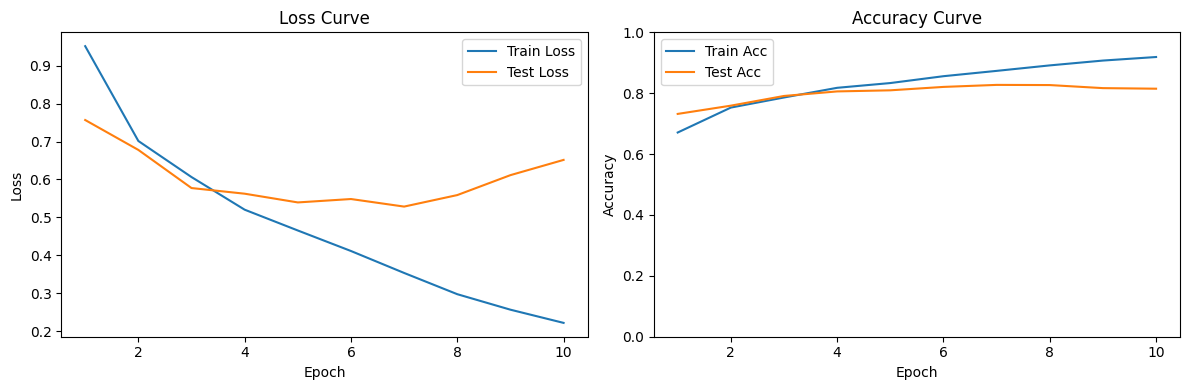

Plot saved to: /content/drive/MyDrive/VehicleClassifier_Yi Lang/Results/Logs/training_curves.png


In [ ]:
# Step 6 (Bonus): Plot training curves

epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, train_losses, label='Train Loss')
ax1.plot(epochs_ran, test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()

ax2.plot(epochs_ran, train_accuracies, label='Train Acc')
ax2.plot(epochs_ran, test_accuracies, label='Test Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plot_path = os.path.join(LOG_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved to: {plot_path}')

In [ ]:
# Final summary

summary_path = os.path.join(SUMMARY_DIR, 'final_summary.txt')

with open(summary_path, 'w') as f:
    f.write('Vehicle Classification CNN: Results Summary\n')
    f.write(f'Device: {device}\n\n')

    f.write('Dataset\n')
    f.write(f'Total images: {len(full_dataset)}\n')
    f.write(f'Training set: {len(train_dataset)}\n')
    f.write(f'Testing set:  {len(test_dataset)}\n')
    f.write(f'Classes: {CLASSES}\n\n')

    f.write('Hyperparameters\n')
    f.write(f'Batch size: {BATCH_SIZE}\n')
    f.write(f'Learning rate: 0.001\n')
    f.write(f'Optimizer: Adam\n')
    f.write(f'Loss function: CrossEntropyLoss\n')
    f.write(f'Max epochs: {EPOCHS}\n')
    f.write(f'Epochs ran: {len(train_losses)}\n\n')

    f.write('Final Results\n')
    f.write(f'Final Training Accuracy:  {train_accuracies[-1]:.4f}\n')
    f.write(f'Final Testing Accuracy:   {test_accuracies[-1]:.4f}\n')
    f.write(f'Best Testing Accuracy:    {best_test_acc:.4f}\n\n')

    f.write('Epoch Log\n')
    f.write(f'{"Epoch":<8}{"Train Loss":<14}{"Train Acc":<14}{"Test Loss":<14}{"Test Acc":<14}\n')
    for i in range(len(train_losses)):
        f.write(f'{i+1:<8}{train_losses[i]:<14.4f}{train_accuracies[i]:<14.4f}'
                f'{test_losses[i]:<14.4f}{test_accuracies[i]:<14.4f}\n')

with open(summary_path, 'r') as f:
    print(f.read())

Vehicle Classification CNN: Results Summary
Device: cuda

Dataset
Total images: 26378
Training set: 21102
Testing set:  5276
Classes: ['Bicycle', 'Bus', 'Car', 'Motorcycle', 'NonVehicles', 'Taxi', 'Truck', 'Van']

Hyperparameters
Batch size: 32
Learning rate: 0.001
Optimizer: Adam
Loss function: CrossEntropyLoss
Max epochs: 10
Epochs ran: 10

Final Results
Final Training Accuracy:  0.9189
Final Testing Accuracy:   0.8148
Best Testing Accuracy:    0.8273

Epoch Log
Epoch   Train Loss    Train Acc     Test Loss     Test Acc      
1       0.9512        0.6709        0.7566        0.7320        
2       0.7014        0.7528        0.6778        0.7591        
3       0.6064        0.7859        0.5774        0.7909        
4       0.5204        0.8177        0.5625        0.8059        
5       0.4656        0.8334        0.5395        0.8095        
6       0.4116        0.8559        0.5485        0.8207        
7       0.3537        0.8734        0.5286        0.8273        
8       0.2